# MG-GAT Interpretability Analysis
**Report Findings Notebook**

Calls functions from `analyze.py`. Run cells top-to-bottom after training is complete.

| Analysis | What it shows |
|---|---|
| 1. NIG Sparsity | Does attention truly filter noisy neighbors? |
| 2. Feature Relevance (FR) | Which features drive neighbor importance? |
| 3. Transparency Validation | Are NIG weights consistent with feature similarity? |
| 4. Case Study | Single recommendation explained with NIG + FR |
| 5. Ablation | NIG-on vs NIG-off RMSE comparison |


In [18]:
import os, sys, json, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
warnings.filterwarnings('ignore')

# Make sure analyze.py is importable
sys.path.insert(0, '.')

from torch.utils.data import DataLoader
from loaddata import load_mggat_data
from models import MGGATRecommender
from analyze import (
    load_trained_model,
    analyze_nig_sparsity,
    extract_and_plot_fr,
    validate_nig_transparency,
    explain_one_recommendation,
    ablation_nig_vs_uniform,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('figures', exist_ok=True)
print(f"Device: {device}")
print("All imports OK ✓")


Device: cuda
All imports OK ✓


## 0. Load Trained Model

In [19]:
model, S_u, S_b, eu, eb, train_ds, tune_ds, test_ds = load_trained_model(
    model_path='final_mggat_model.pth',
    hyperparams_path='best_hyperparameters.json',
    device=device
)

test_loader  = DataLoader(test_ds,  batch_size=2048, shuffle=False)
tune_loader  = DataLoader(tune_ds,  batch_size=2048, shuffle=False)

# Load feature names from CSV headers
DATA_DIR = 'dataset/PA/'
df_user_feat = pd.read_csv(os.path.join(DATA_DIR, 'user_features.csv'))
df_item_feat = pd.read_csv(os.path.join(DATA_DIR, 'item_features.csv'))
feature_names_user = list(df_user_feat.columns)
feature_names_biz  = list(df_item_feat.columns)

print(f"Users:             {S_u.shape[0]:,}  |  User feature dim:  {S_u.shape[1]}")
print(f"Businesses:        {S_b.shape[0]:,}  |  Biz feature dim:   {S_b.shape[1]}")
print(f"User feature names (first 5):  {feature_names_user[:5]}")
print(f"Biz  feature names (first 5):  {feature_names_biz[:5]}")


Loading data...
Model loaded from final_mggat_model.pth
Users:             76,864  |  User feature dim:  32
Businesses:        10,966  |  Biz feature dim:   1223
User feature names (first 5):  ['compliments: hot', 'compliments: more', 'compliments: profile', 'compliments: cute', 'compliments: list']
Biz  feature names (first 5):  ['categories: & Probates', 'categories: Active Life: ATV Rentals/Tours', 'categories: Food: Acai Bowls', 'categories: Shopping: Fashion: Accessories', 'categories: Professional Services: Accountants']


### Model Parameter Overview

In [20]:
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable:,}")
print()
print("Key interpretability parameters:")
print(f"  user_gat.a_self  shape: {model.user_gat.a_self.shape}")
print(f"  user_gat.a_nb    shape: {model.user_gat.a_nb.shape}")
print(f"  user_gat.W_1     shape: {model.user_gat.W_1.weight.shape}")
print(f"  item_gat.omega   values: {model.item_gat.omega.detach().cpu().numpy().round(4)}")
print(f"  item_gat.a_self  shape: {model.item_gat.a_self.shape}")
print(f"  item_gat.a_nb    shape: {model.item_gat.a_nb.shape}")


Total parameters:     5,886,363
Trainable parameters: 5,886,363

Key interpretability parameters:
  user_gat.a_self  shape: torch.Size([1, 64])
  user_gat.a_nb    shape: torch.Size([1, 64])
  user_gat.W_1     shape: torch.Size([64, 32])
  item_gat.omega   values: [1.4666 1.4092]
  item_gat.a_self  shape: torch.Size([1, 64])
  item_gat.a_nb    shape: torch.Size([1, 64])


---
## Analysis 1: NIG Sparsity
**Question:** Does NIG truly filter noisy neighbors, or does it behave like uniform attention?

**Method:** Compute Gini coefficient and top-1 weight share for each node's attention distribution.
- Gini = 0 → perfectly uniform (no filtering)
- Gini → 1 → all weight on one neighbor (maximum filtering)


In [21]:
nig_results = analyze_nig_sparsity(
    model, S_u, S_b, eu, eb, device,
    num_samples=2000,
    output_dir='figures'
)



──────────────────────────────────────────────────
[NIG Sparsity] User side  (n_nodes = 1416)
  Gini coefficient:  mean=0.0126  median=0.0049
  Top-1 weight share: 0.2448  vs. uniform=0.2397
  Top-3 weight share: 0.6110
  NIG selectivity ratio (top-1 / uniform): 1.02x
  Figure saved → figures/nig_sparsity_user.png

──────────────────────────────────────────────────
[NIG Sparsity] Business side  (n_nodes = 1738)
  Gini coefficient:  mean=0.0452  median=0.0401
  Top-1 weight share: 0.1798  vs. uniform=0.1616
  Top-3 weight share: 0.4526
  NIG selectivity ratio (top-1 / uniform): 1.11x
  Figure saved → figures/nig_sparsity_business.png


=== User NIG Sparsity ===


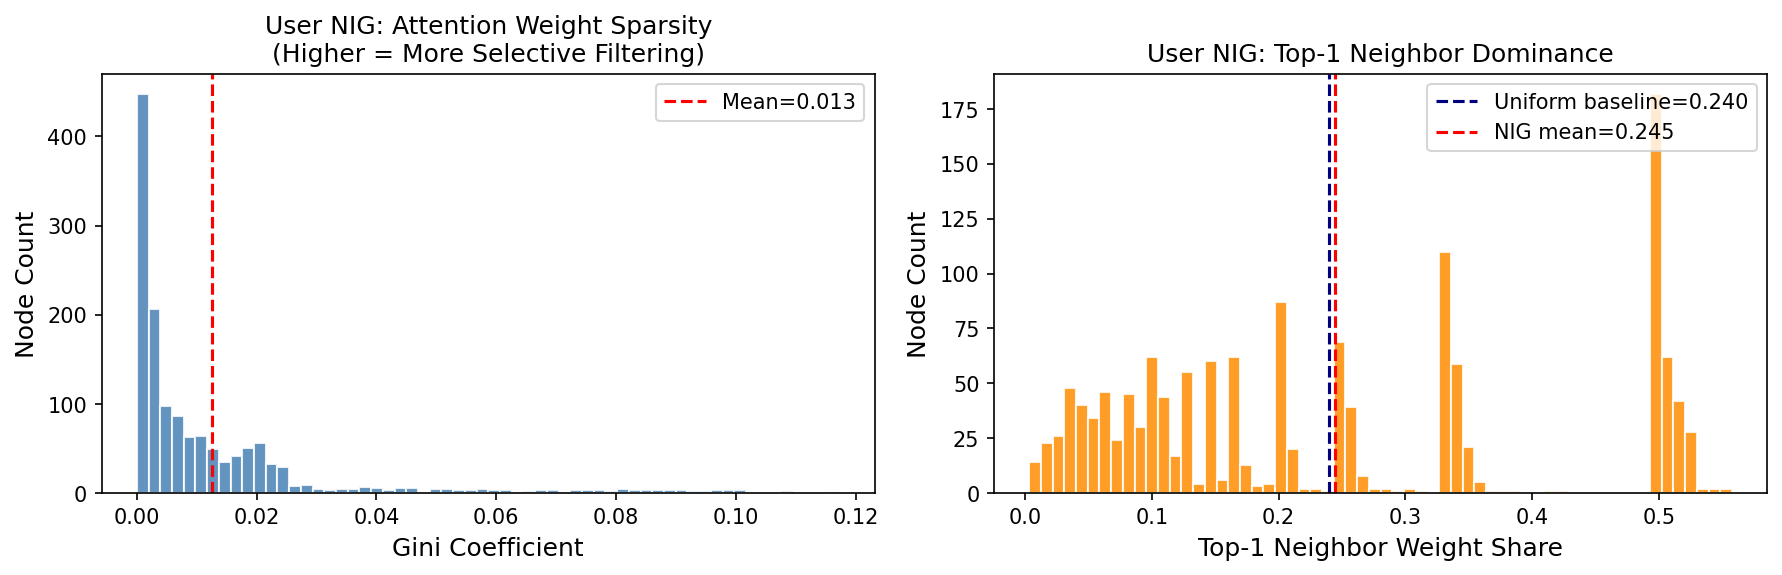


=== Business NIG Sparsity ===


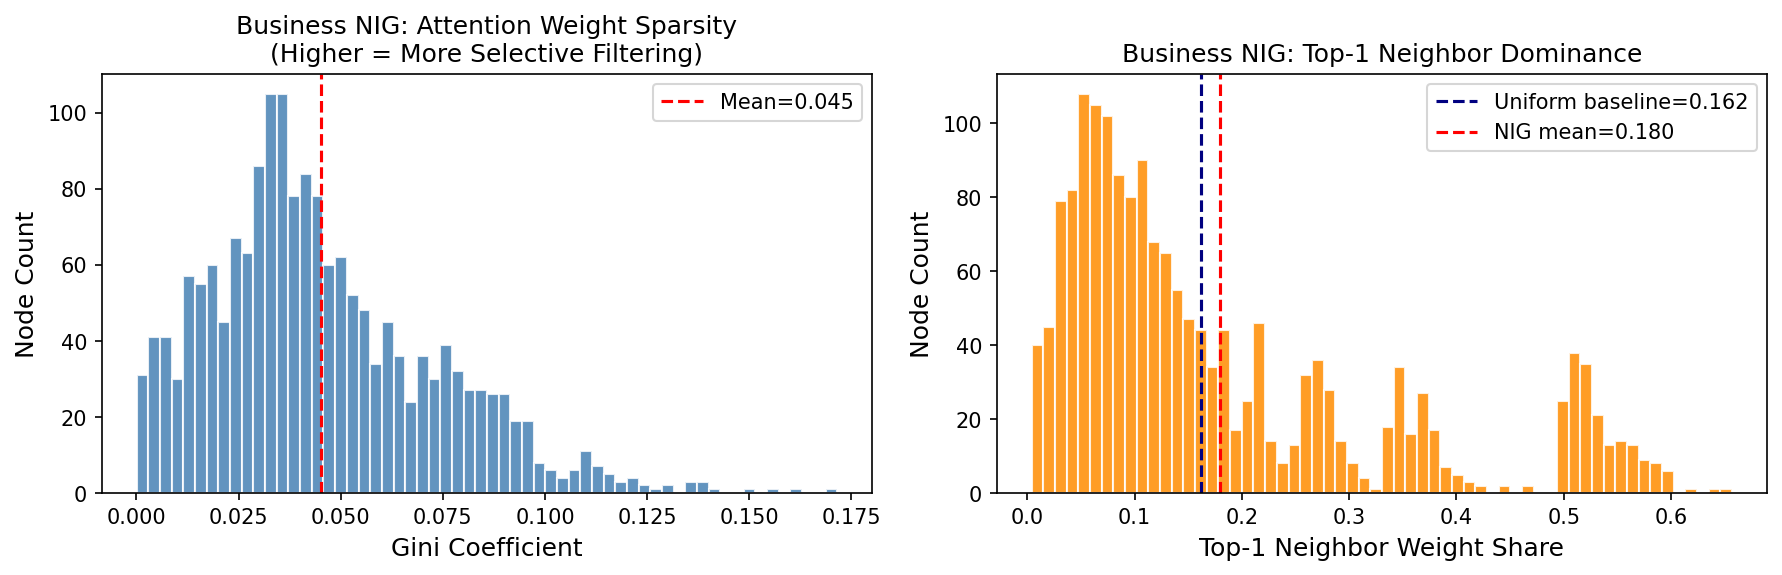

In [22]:
# Display the saved figures inline
from IPython.display import Image, display

print("=== User NIG Sparsity ===")
display(Image('figures/nig_sparsity_user.png'))
print("\n=== Business NIG Sparsity ===")
display(Image('figures/nig_sparsity_business.png'))


In [23]:
# Summary statistics for report table
for side in ['User', 'Business']:
    r = nig_results[side]
    print(f"[{side}]")
    print(f"  Gini:           mean={r['gini'].mean():.4f}  median={np.median(r['gini']):.4f}  std={r['gini'].std():.4f}")
    print(f"  Top-1 share:    mean={r['top1'].mean():.4f}")
    print(f"  Top-3 share:    mean={r['top3'].mean():.4f}")
    print(f"  Uniform top-1:  {r['uniform_top1']:.4f}")
    ratio = r['top1'].mean() / r['uniform_top1']
    print(f"  Selectivity ratio (NIG / Uniform): {ratio:.2f}x")
    print()


[User]
  Gini:           mean=0.0126  median=0.0049  std=0.0192
  Top-1 share:    mean=0.2448
  Top-3 share:    mean=0.6110
  Uniform top-1:  0.2397
  Selectivity ratio (NIG / Uniform): 1.02x

[Business]
  Gini:           mean=0.0452  median=0.0401  std=0.0274
  Top-1 share:    mean=0.1798
  Top-3 share:    mean=0.4526
  Uniform top-1:  0.1616
  Selectivity ratio (NIG / Uniform): 1.11x



---
## Analysis 2: Feature Relevance (FR)
**Question:** Which auxiliary features drive neighbor importance (NIG)?

**Method:** Extract FR weights directly from model parameters (Definition 2 in paper).

`FR_focal = a_self^T @ W1`  
`FR_neighbor = (Σ ω_g) * a_nb^T @ W1`

Compare with paper's claim for PA: *"good for groups, reservations, table service, good for kids, alcohol"*


In [24]:
all_fr = extract_and_plot_fr(
    model,
    feature_names_user=feature_names_user,
    feature_names_biz=feature_names_biz,
    top_k=20,
    output_dir='figures'
)



──────────────────────────────────────────────────
[FR] Top-20 User Features driving NIG:
  # 1 (-)  elite_2014                                     FR=0.2294
  # 2 (+)  elite_2018                                     FR=0.2167
  # 3 (-)  yelping_since_day                              FR=0.2016
  # 4 (+)  elite_2011                                     FR=0.1399
  # 5 (-)  yelping_since_year                             FR=0.1233
  # 6 (-)  elite_2013                                     FR=0.1186
  # 7 (+)  elite_2012                                     FR=0.1155
  # 8 (-)  elite_2017                                     FR=0.1144
  # 9 (+)  elite_2015                                     FR=0.1132
  #10 (+)  elite_2016                                     FR=0.1064
  #11 (-)  yelping_since_month                            FR=0.0952
  #12 (+)  fans                                           FR=0.0680
  #13 (+)  elite_2010                                     FR=0.0529
  #14 (+)  elite_2009    

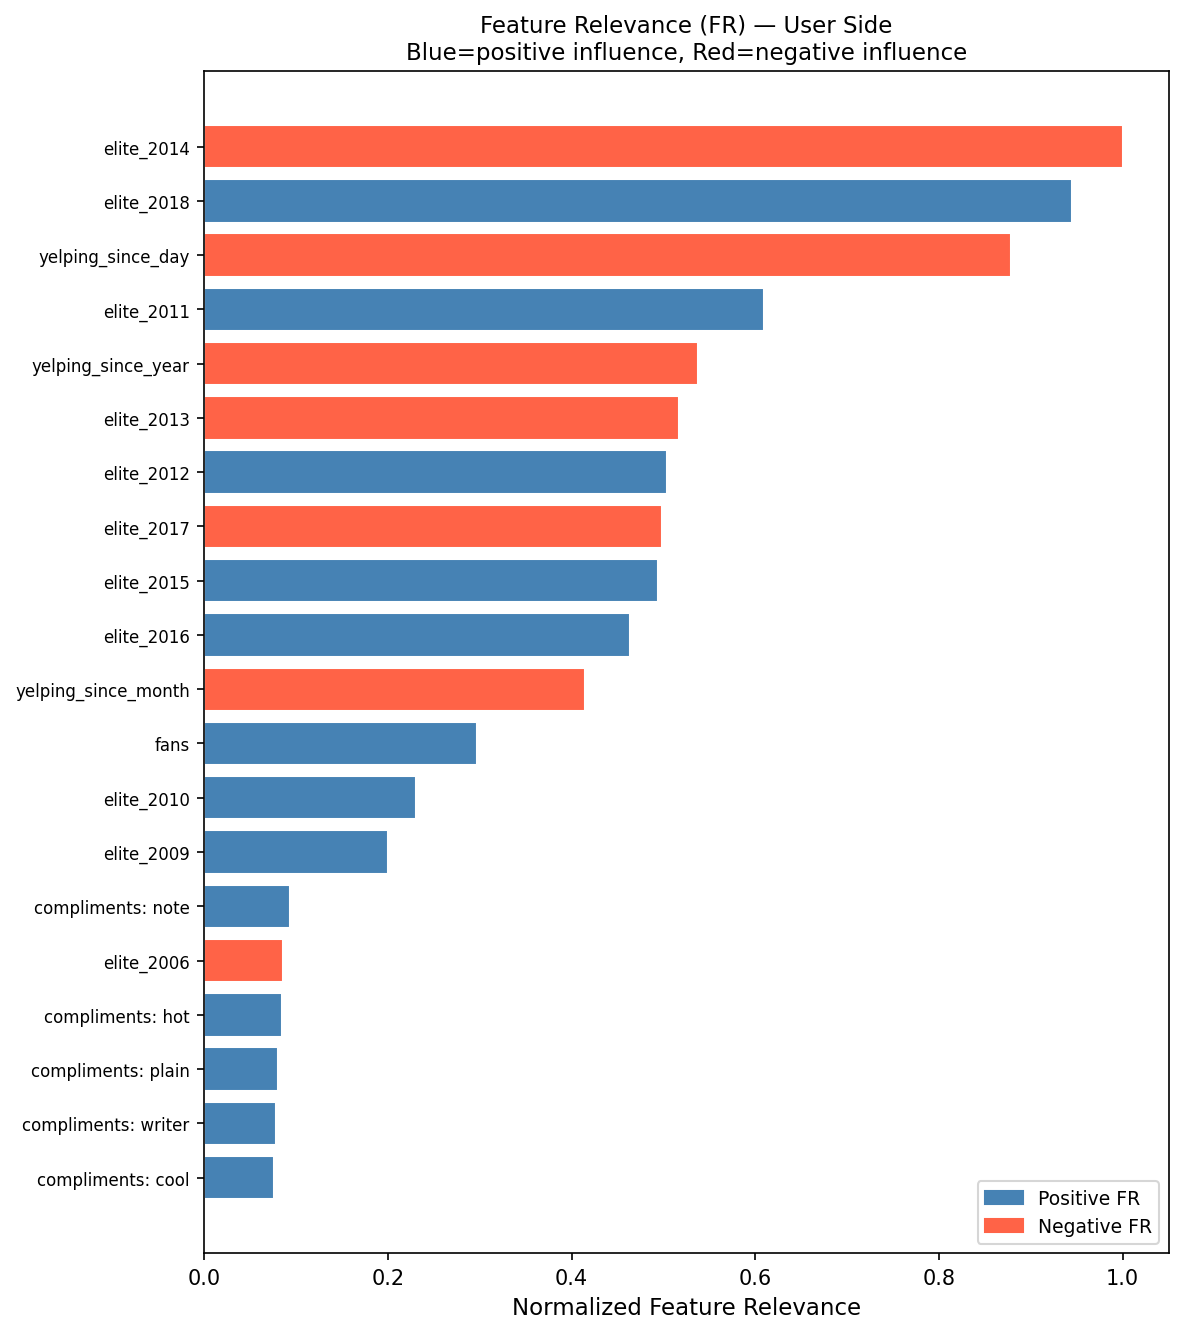

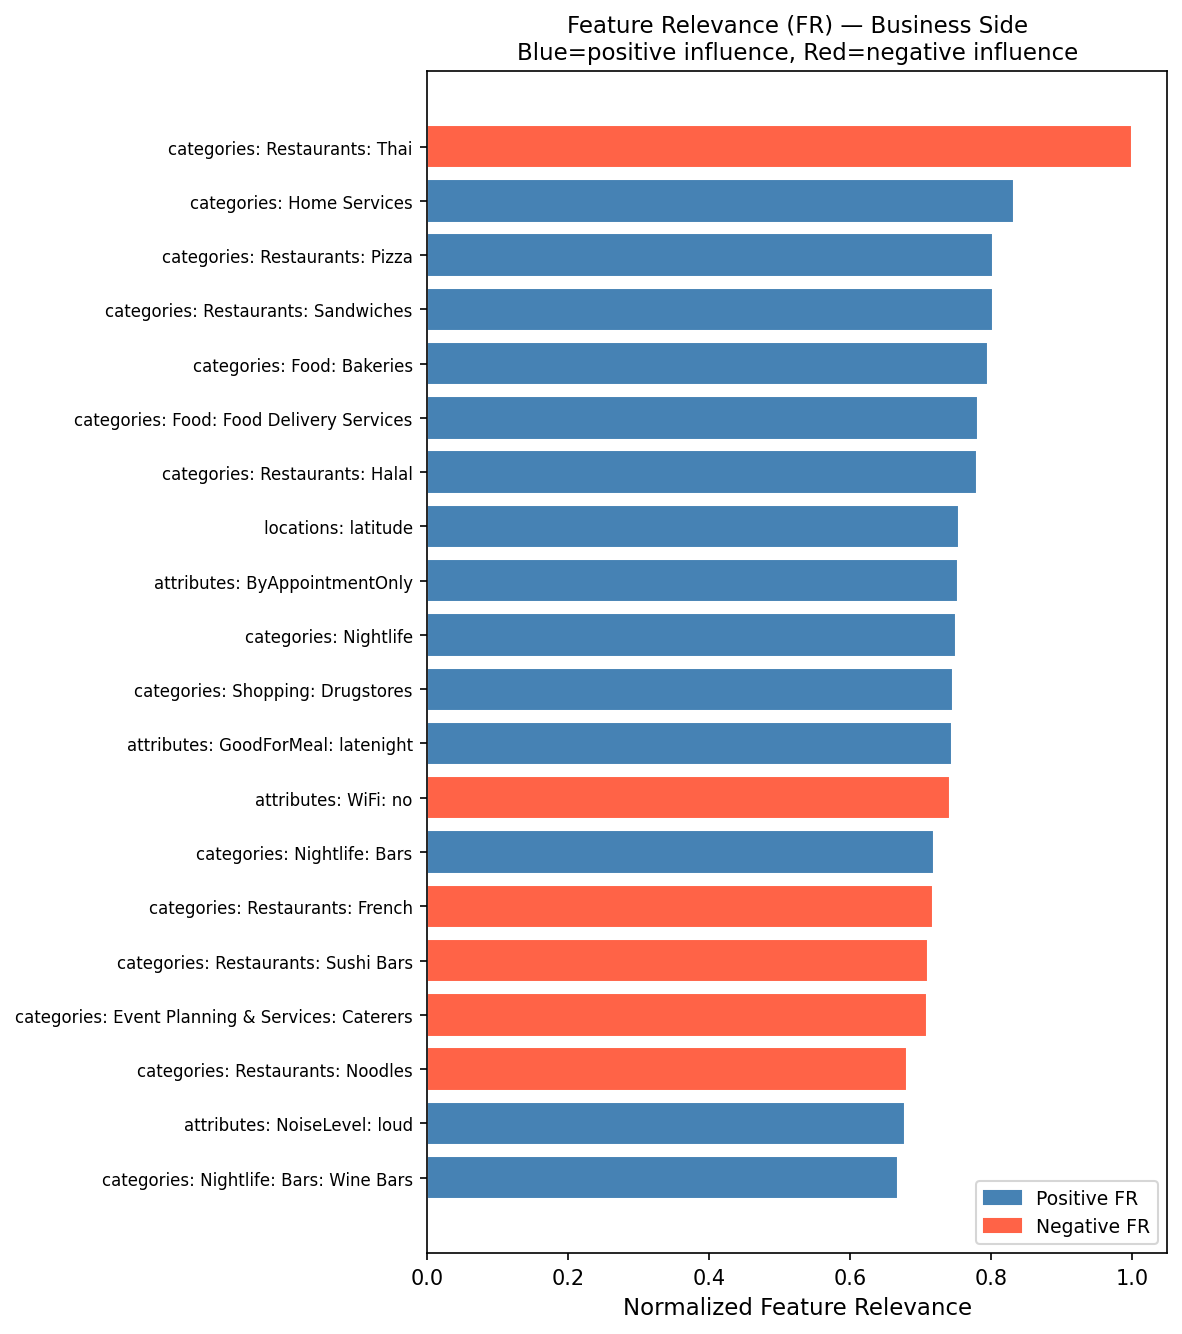

In [25]:
display(Image('figures/fr_user.png'))
display(Image('figures/fr_business.png'))


In [26]:
# Side-by-side: focal vs neighbor FR (signed, for richer analysis)
W1_b    = model.item_gat.W_1.weight.detach().cpu().numpy()
ab_self = model.item_gat.a_self.detach().cpu().numpy()
ab_nb   = model.item_gat.a_nb.detach().cpu().numpy()
omega   = model.item_gat.omega.detach().cpu().numpy()

FR_focal_b    = (ab_self @ W1_b).squeeze()
FR_neighbor_b = omega.sum() * (ab_nb @ W1_b).squeeze()

top20_idx = np.argsort(np.abs(FR_focal_b) + np.abs(FR_neighbor_b))[::-1][:20]
df_fr = pd.DataFrame({
    'feature':         [feature_names_biz[i] for i in top20_idx],
    'FR_focal':        FR_focal_b[top20_idx].round(4),
    'FR_neighbor':     FR_neighbor_b[top20_idx].round(4),
    'FR_combined_abs': (np.abs(FR_focal_b) + np.abs(FR_neighbor_b))[top20_idx].round(4),
}).reset_index(drop=True)
df_fr.index += 1
print("Top-20 Business Feature Relevance:")
print(df_fr.to_string())


Top-20 Business Feature Relevance:
                                            feature  FR_focal  FR_neighbor  FR_combined_abs
1                     categories: Restaurants: Thai    0.0350      -0.3460           0.3810
2                         categories: Home Services   -0.0113       0.3058           0.3171
3                    categories: Restaurants: Pizza    0.0222       0.2835           0.3057
4               categories: Restaurants: Sandwiches   -0.0059       0.2997           0.3055
5                        categories: Food: Bakeries   -0.0241       0.2789           0.3031
6          categories: Food: Food Delivery Services   -0.0032       0.2946           0.2978
7                    categories: Restaurants: Halal   -0.0034       0.2935           0.2969
8                               locations: latitude    0.0087       0.2788           0.2876
9                     attributes: ByAppointmentOnly   -0.0097       0.2774           0.2871
10                            categories: Nig

---
## Analysis 3: IS Transparency Validation
**Question:** Are NIG attention weights consistent with feature-level similarity?

If NIG weights correlate positively with cosine feature similarity, it means  
the model's attention mechanism is **grounded in observable features** — directly  
supporting the paper's transparency claim (Tintarev & Masthoff 2012).


In [27]:
corr_arr = validate_nig_transparency(
    model, S_b, eb, device,
    sample_nodes=1000
)



──────────────────────────────────────────────────
[Transparency Validation] NIG weights vs. Feature Similarity
  Nodes analyzed: 785
  Mean Spearman r = -0.0946  (std=0.5325)
  Median Spearman r = -0.1390
  % nodes with positive r = 41.9%
  % nodes with r > 0.3   = 25.6%
  % nodes significant (p<0.05) = 33.5%
  Interpretation: Weak: NIG operates beyond raw feature similarity (learned non-linear filtering)
  Figure saved → figures/transparency_validation.png


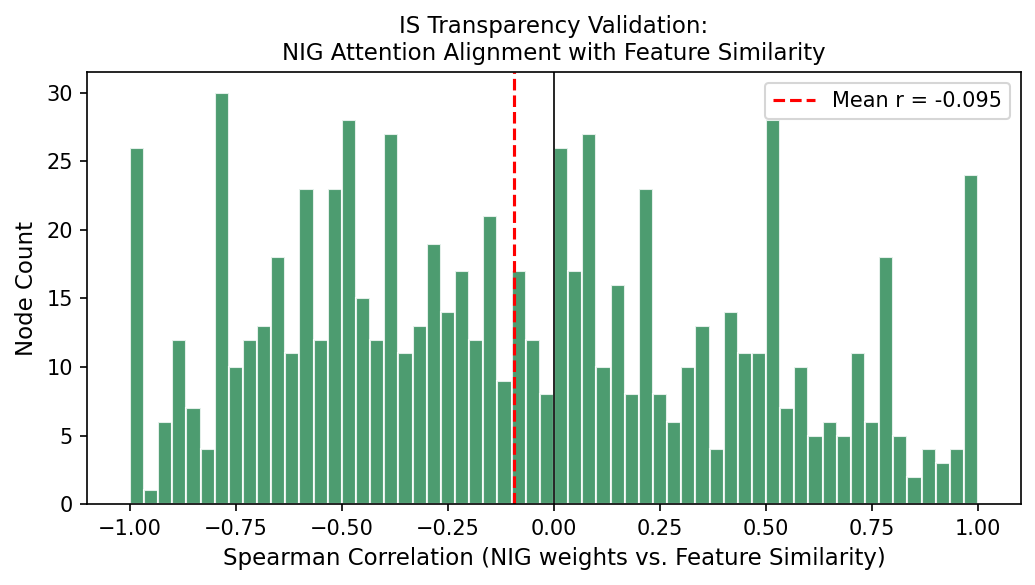

Mean Spearman r:      -0.0946
Std:                  0.5325
% positive:           41.9%
% r > 0.3:            25.6%


In [28]:
display(Image('figures/transparency_validation.png'))

# Report-ready statistics
print(f"Mean Spearman r:      {corr_arr.mean():.4f}")
print(f"Std:                  {corr_arr.std():.4f}")
print(f"% positive:           {(corr_arr > 0).mean()*100:.1f}%")
print(f"% r > 0.3:            {(corr_arr > 0.3).mean()*100:.1f}%")


---
## Analysis 4: Case Study — Single Recommendation Explained
Mirrors the qualitative examples in **Appendix G** of the paper.  
Change `user_id` and `item_id` to a real high-rated pair from the test set.


In [29]:
# Find a real high-rated pair from test set for a better example
test_df = pd.read_csv('dataset/PA/data.csv')
test_df = test_df[test_df['is_test'] == True]
high_rated = test_df[test_df['rating'] >= 4].head(5)
print("Example high-rated test pairs to use:")
print(high_rated[['user_id', 'item_id', 'rating']].to_string())


Example high-rated test pairs to use:
      user_id  item_id  rating
70        390     5189     5.0
319      2090     4955     5.0
3407     1730     7263     5.0
5019     1267     3568     5.0
6202     3076     6638     5.0


In [30]:
# ← Change these to a pair from the table above
USER_ID = 0
ITEM_ID = 0

explain_one_recommendation(
    model,
    user_id=USER_ID,
    item_id=ITEM_ID,
    S_u=S_u, S_b=S_b, eu=eu, eb=eb,
    feature_names_user=feature_names_user,
    feature_names_biz=feature_names_biz,
    device=device,
    top_k_fr=5,
    top_k_nb=3
)



RECOMMENDATION EXPLANATION
  User ID:        0
  Business ID:    0
  Predicted Rating: 4.79 / 5.0

[NIG] Top-3 Most Similar Businesses (Neighbor Importance):
  #1  Business 6136  |  α = 0.0425
  #2  Business 5103  |  α = 0.0393
  #3  Business 2959  |  α = 0.0390

[FR] Top-5 Features Driving Neighbor Selection:
  #1  categories: Restaurants: Thai             FR=0.3810  (negative)
  #2  categories: Home Services                 FR=0.3171  (positive)
  #3  categories: Restaurants: Pizza            FR=0.3057  (positive)
  #4  categories: Restaurants: Sandwiches       FR=0.3055  (positive)
  #5  categories: Food: Bakeries                FR=0.3031  (positive)

[IS Transparency] Plain-language explanation:
  Business 0 is recommended because it is most similar to
  Business 6136 (weight=0.043).
  The similarity is primarily driven by: categories: Restaurants: Thai, categories: Home Services, categories: Restaurants: Pizza


---
## Analysis 5: Ablation — NIG vs Uniform Attention
Zero out `a_self` and `a_nb` at inference time → attention becomes uniform.  
Measures how much RMSE degrades without selective neighbor weighting.

> **Note:** This is inference-time ablation (weight zeroing), not full retraining.  
> Full retraining ablation from paper (PA): RMSE = 1.303 (NIG removed).


In [31]:
rmse_nig, rmse_uniform = ablation_nig_vs_uniform(
    model, test_loader, S_u, S_b, eu, eb, device
)



──────────────────────────────────────────────────
[Ablation: NIG vs Uniform Attention]
  RMSE with NIG (trained):   1.4191
  RMSE with Uniform (zeroed): 1.4187
  NIG improvement: -0.03%
  Note: This uses weight-zeroing, not full retraining.
        True ablation RMSE from paper (PA): 1.303 (NIG removed)


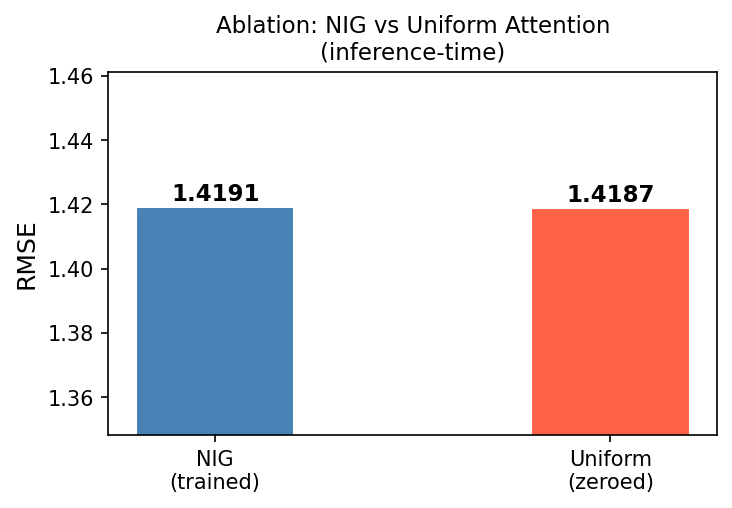

In [32]:
# Visualize ablation comparison
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(['NIG\n(trained)', 'Uniform\n(zeroed)'],
               [rmse_nig, rmse_uniform],
               color=['steelblue', 'tomato'], width=0.4, edgecolor='white')
for bar, val in zip(bars, [rmse_nig, rmse_uniform]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Ablation: NIG vs Uniform Attention\n(inference-time)', fontsize=11)
ax.set_ylim(rmse_nig * 0.95, rmse_uniform * 1.03)
plt.tight_layout()
plt.savefig('figures/ablation_nig.png', dpi=150, bbox_inches='tight')
plt.show()
display(Image('figures/ablation_nig.png'))


---
## Bonus: Multi-Graph Weights (ω_g)
The paper uses 4 business graph types: geographic, co-visit, category, LLM perceptual.  
Your implementation uses 2 graphs (1-hop + 2-hop).  
The learned ω weights tell us which graph contributes more.


User graph weights (ω_g):
  Graph 0 (1-hop):  raw=0.6805  softmax=0.4866
  Graph 1 (2-hop):  raw=0.7341  softmax=0.5134

Business graph weights (ω_g):
  Graph 0 (1-hop):  raw=1.4666  softmax=0.5143
  Graph 1 (2-hop):  raw=1.4092  softmax=0.4857


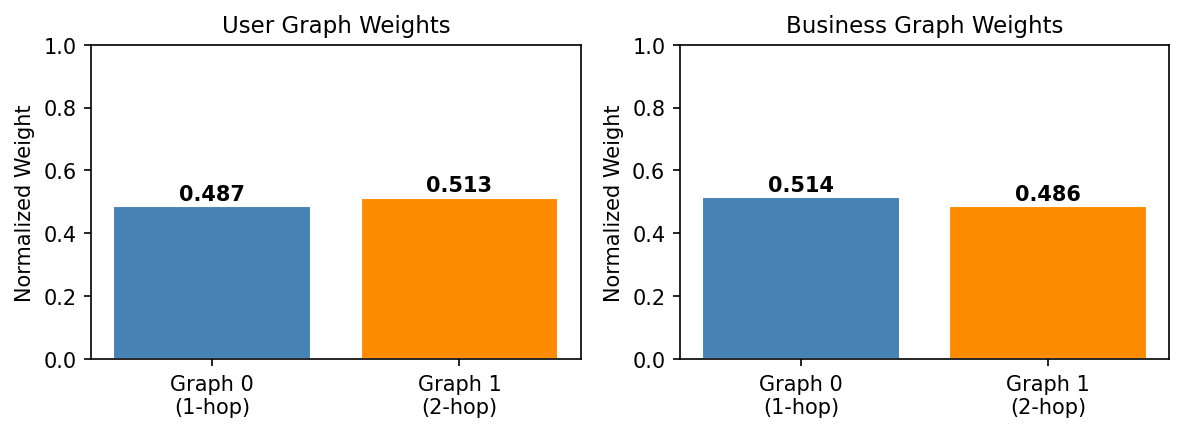

In [33]:
omega_u = model.user_gat.omega.detach().cpu().numpy()
omega_b = model.item_gat.omega.detach().cpu().numpy()

# Normalize to sum=1 for interpretability
omega_u_norm = np.exp(omega_u) / np.exp(omega_u).sum()
omega_b_norm = np.exp(omega_b) / np.exp(omega_b).sum()

print("User graph weights (ω_g):")
for g, (raw, norm) in enumerate(zip(omega_u, omega_u_norm)):
    print(f"  Graph {g} ({'1-hop' if g==0 else '2-hop'}):  raw={raw:.4f}  softmax={norm:.4f}")

print("\nBusiness graph weights (ω_g):")
for g, (raw, norm) in enumerate(zip(omega_b, omega_b_norm)):
    print(f"  Graph {g} ({'1-hop' if g==0 else '2-hop'}):  raw={raw:.4f}  softmax={norm:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, omega_n, title in zip(axes,
    [omega_u_norm, omega_b_norm],
    ['User Graph Weights', 'Business Graph Weights']):
    labels = [f'Graph {g}\n({"1-hop" if g==0 else "2-hop"})' for g in range(len(omega_n))]
    ax.bar(labels, omega_n, color=['steelblue', 'darkorange'], edgecolor='white')
    ax.set_ylabel('Normalized Weight', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1)
    for i, v in enumerate(omega_n):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/omega_weights.png', dpi=150, bbox_inches='tight')
plt.show()
display(Image('figures/omega_weights.png'))


---
## Report Summary Table
Copy these numbers into your report.


In [34]:
print("=" * 60)
print("FINDINGS SUMMARY FOR REPORT")
print("=" * 60)

# NIG
u_gini = nig_results['User']['gini'].mean()
b_gini = nig_results['Business']['gini'].mean()
u_ratio = nig_results['User']['top1'].mean() / nig_results['User']['uniform_top1']
b_ratio = nig_results['Business']['top1'].mean() / nig_results['Business']['uniform_top1']

print(f"\n1. NIG Sparsity")
print(f"   User     Gini={u_gini:.3f}  Selectivity={u_ratio:.2f}x over uniform")
print(f"   Business Gini={b_gini:.3f}  Selectivity={b_ratio:.2f}x over uniform")

print(f"\n2. Transparency (NIG vs Feature Similarity)")
print(f"   Mean Spearman r = {corr_arr.mean():.3f}  (% positive: {(corr_arr>0).mean()*100:.1f}%)")

print(f"\n3. Ablation (inference-time)")
print(f"   RMSE with NIG:     {rmse_nig:.4f}")
print(f"   RMSE uniform:      {rmse_uniform:.4f}")
print(f"   Improvement:       {(rmse_uniform-rmse_nig)/rmse_uniform*100:+.2f}%")

print(f"\n4. Figures generated in ./figures/")
for f in sorted(os.listdir('figures')):
    print(f"   {f}")


FINDINGS SUMMARY FOR REPORT

1. NIG Sparsity
   User     Gini=0.013  Selectivity=1.02x over uniform
   Business Gini=0.045  Selectivity=1.11x over uniform

2. Transparency (NIG vs Feature Similarity)
   Mean Spearman r = -0.095  (% positive: 41.9%)

3. Ablation (inference-time)
   RMSE with NIG:     1.4191
   RMSE uniform:      1.4187
   Improvement:       -0.03%

4. Figures generated in ./figures/
   ablation_nig.png
   fr_business.png
   fr_user.png
   nig_sparsity_business.png
   nig_sparsity_user.png
   omega_weights.png
   transparency_validation.png
